In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [53]:
df = pd.read_csv("Instagram visits clustering.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
   User ID  Instagram visit score  Spending_rank(0 to 100)
0        0                     63                24.050708
1        1                     61                25.223290
2        2                    104                18.528245
3        3                     82                86.890232
4        4                     14                31.492397


In [54]:
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(2600, 3)


In [55]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['User ID', 'Instagram visit score', 'Spending_rank(0 to 100)'], dtype='str')


In [56]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2600 non-null   int64  
 1   Instagram visit score    2600 non-null   int64  
 2   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 61.1 KB


In [57]:

print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
           User ID  Instagram visit score  Spending_rank(0 to 100)
count  2600.000000            2600.000000              2600.000000
mean   1299.500000              63.323462                42.848408
std     750.699674              26.579760                28.758349
min       0.000000               5.000000                 0.940709
25%     649.750000              38.000000                19.452098
50%    1299.500000              72.000000                28.013082
75%    1949.250000              86.000000                72.116945
max    2599.000000             118.000000               107.349821


In [58]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
User ID                    0
Instagram visit score      0
Spending_rank(0 to 100)    0
dtype: int64


In [59]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


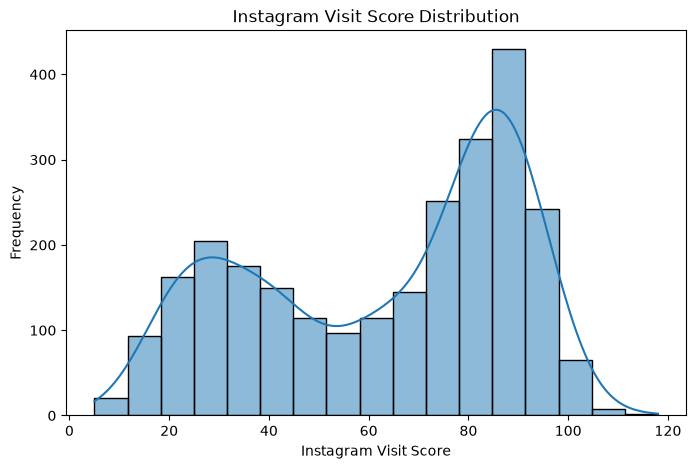

In [60]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Instagram visit score"],
    kde=True
)
plt.title("Instagram Visit Score Distribution")
plt.xlabel("Instagram Visit Score")
plt.ylabel("Frequency")
plt.show()


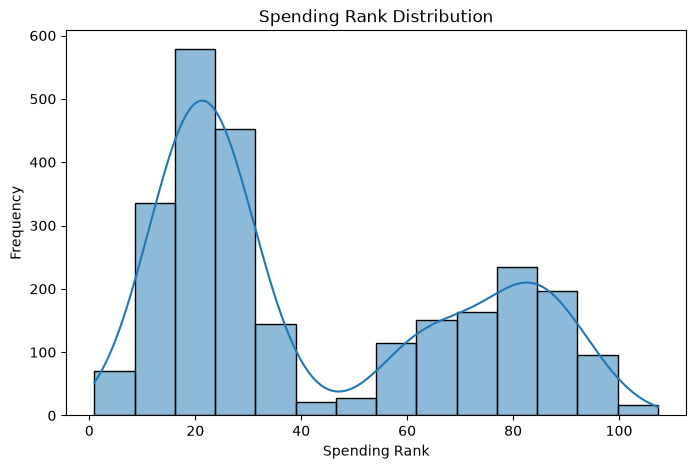

In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Spending_rank(0 to 100)"],
    kde=True
)
plt.title("Spending Rank Distribution")
plt.xlabel("Spending Rank")
plt.ylabel("Frequency")

plt.show()


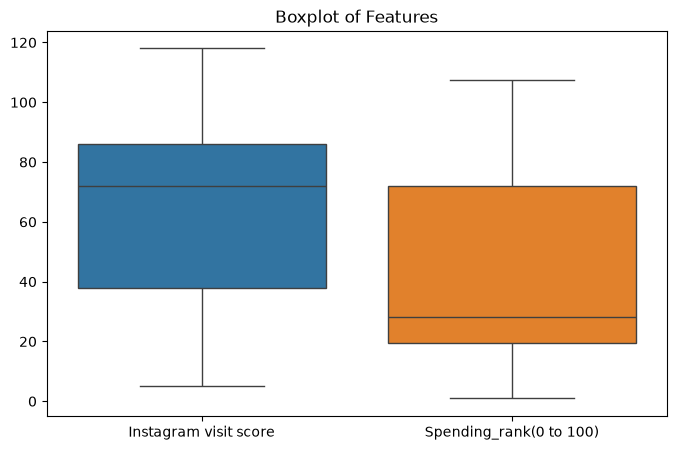

In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df[
        [
            "Instagram visit score",
            "Spending_rank(0 to 100)"
        ]
    ]
)
plt.title("Boxplot of Features")
plt.show()

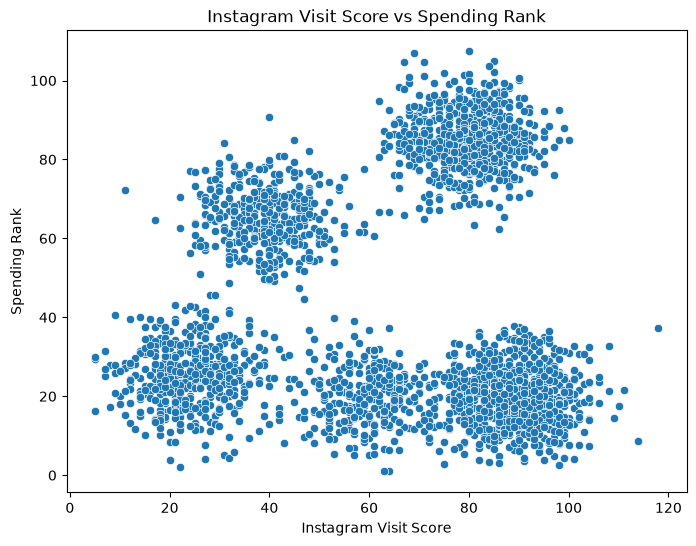

In [63]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Instagram visit score",
    y="Spending_rank(0 to 100)"
)
plt.title("Instagram Visit Score vs Spending Rank")
plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending Rank")
plt.show()

In [64]:
# User ID is not used because it is only an identifier
X = df[
    [
        "Instagram visit score",
        "Spending_rank(0 to 100)"
    ]
]

In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [66]:
wcss = []
for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

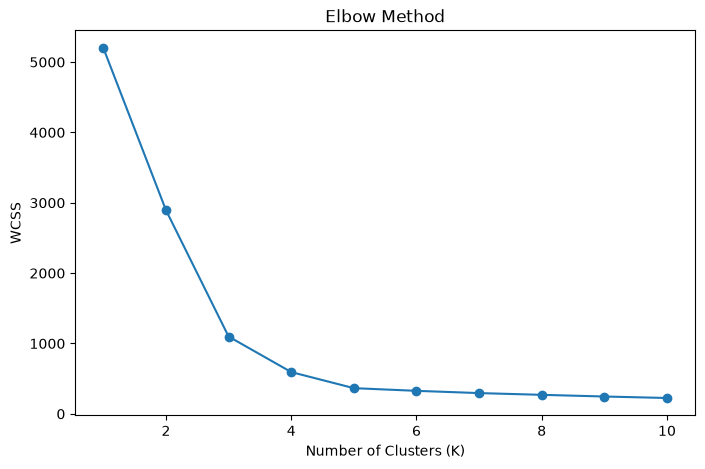

In [67]:

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [68]:
# From Elbow Method, choose K = 4
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [69]:
print("\nCluster Counts:")

print(
    df["Cluster"]
    .value_counts()
    .sort_index()
)


Cluster Counts:
Cluster
0    1027
1     400
2     600
3     573
Name: count, dtype: int64


In [70]:
centroids_scaled = kmeans.cluster_centers_

# Convert scaled centroids back to original values
centroids = scaler.inverse_transform(
    centroids_scaled
)

print("\nCluster Centroids:")

print(centroids)


Cluster Centroids:
[[83.24342746 19.87248561]
 [39.35       65.13248481]
 [79.615      85.0244978 ]
 [27.29668412 24.30911866]]


<Axes: xlabel='Instagram visit score', ylabel='Spending_rank(0 to 100)'>

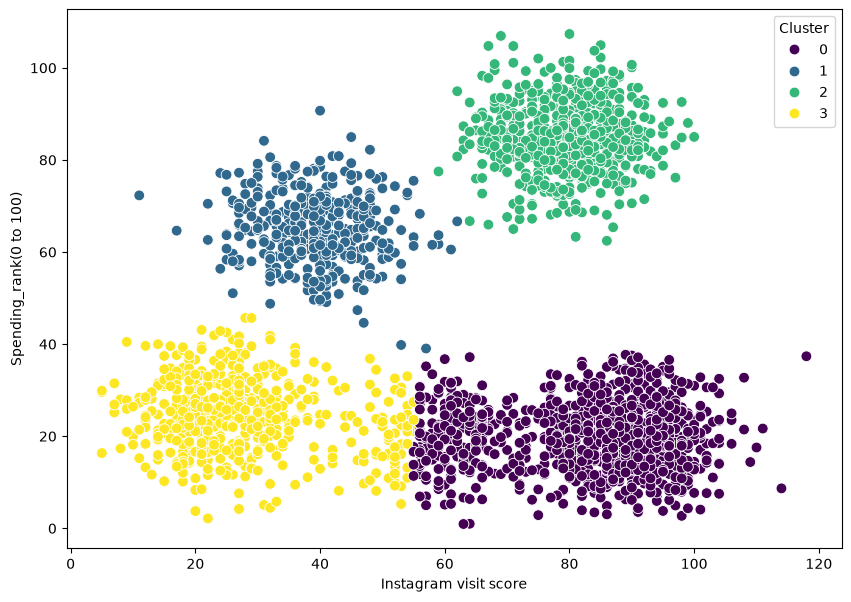

In [71]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="Instagram visit score",
    y="Spending_rank(0 to 100)",
    hue="Cluster",
    palette="viridis",
    s=60
)

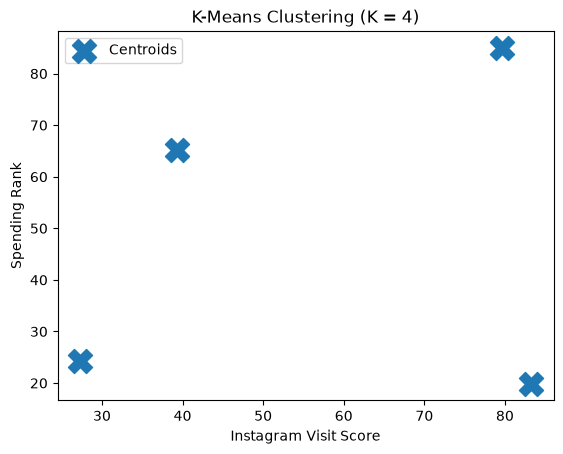

In [72]:
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=300,
    label="Centroids"
)

plt.title("K-Means Clustering (K = 4)")
plt.xlabel("Instagram Visit Score")
plt.ylabel("Spending Rank")

plt.legend()

plt.show()

   User ID  Instagram visit score  Spending_rank(0 to 100)
0        0                     63                24.050708
1        1                     61                25.223290
2        2                    104                18.528245
3        3                     82                86.890232
4        4                     14                31.492397
(2600, 3)


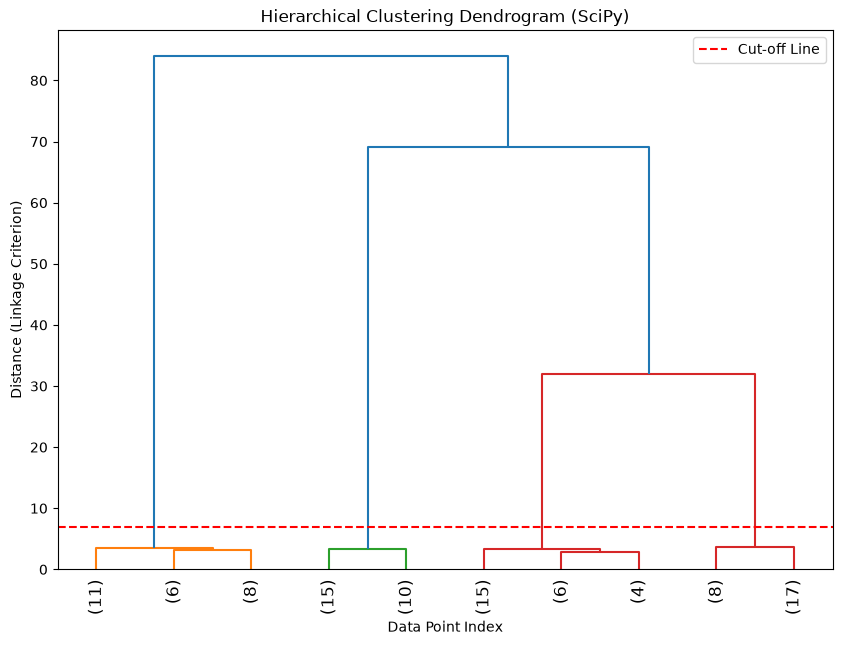

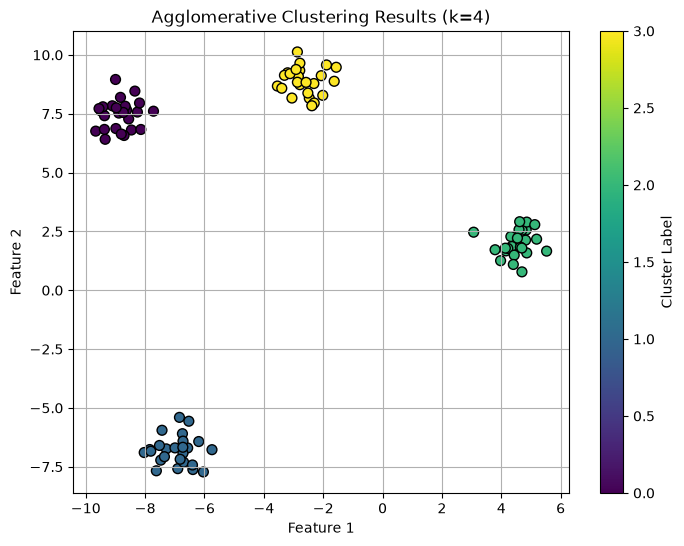

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# --- 1. Generate Synthetic Data ---
# We'll create 100 data points with 2 features (X, y coordinates)
# and an intrinsic structure of 4 'blobs' (clusters) for visualization.
df=pd.read_csv("Instagram visits clustering.csv")
print(df.head())
print(df.shape)

# --- 2. Hierarchical Clustering using SciPy (for Dendrogram) ---

# The linkage function performs the hierarchical clustering.
# 'ward' method minimizes the variance of the clusters being merged.
# 'euclidean' is the standard distance metric used.
linked = linkage(X, method='ward', metric='euclidean')

# --- 3. Plot the Dendrogram ---
plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram (SciPy)")
plt.xlabel("Data Point Index")
plt.ylabel("Distance (Linkage Criterion)")

# Generate and plot the dendrogram
# truncate_mode='lastp' shows only the last 'p' merged clusters
# p=10 shows the last 10 merged clusters for a cleaner plot
dendrogram(
    linked,
    orientation='top',
    truncate_mode='lastp',
    p=10,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=12.,
)
plt.axhline(y=7, color='r', linestyle='--', label='Cut-off Line')
plt.legend()
plt.show()

# --- 4. Applying Agglomerative Clustering using Scikit-learn ---

# Based on the dendrogram, we can choose the number of clusters (k).
# If we cut the dendrogram at a distance of ~7 (red dashed line),
# it intersects 4 main branches, suggesting k=4.
n_clusters_chosen = 4

# Initialize the Agglomerative Clustering model
# We use the same 'linkage' and 'metric' as used for the dendrogram.
hac = AgglomerativeClustering(n_clusters=n_clusters_chosen, metric='euclidean', linkage='ward')

# Fit the model and predict the cluster labels
hac_labels = hac.fit_predict(X)

# --- 5. Visualize the Final Clusters ---
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=hac_labels, cmap='viridis', marker='o', s=50, edgecolors='k')
plt.title(f"Agglomerative Clustering Results (k={n_clusters_chosen})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()